# Strategy Research & Signal Diagnostics

**Purpose.** The research notebook a quant runs *before* a strategy is proposed for
capital: does the signal actually do anything sensible, how do different portfolio
construction choices change the outcome, and is there anything about the trade log
or exposure profile that would make a PM uncomfortable.

**Pipeline under test:**

```
Prices -> Strategy -> Signals -> PortfolioAllocator -> Target Weights
    -> PositionSizer -> Share Sizes -> VectorBT Backtester
```

Everything below runs through the actual project modules (`strategy_engine`,
`signal_generator`, `portfolio_engine`, `backtester`, `performance_analytics`) --
this notebook does not reimplement any logic, it only visualizes and stress-tests
what those modules produce, so what you see here is exactly what `main.py` would
give you.

## 0. Setup

In [ ]:
import sys
from pathlib import Path

# Make sure the project root (where config.py lives) is importable, no matter which directory 
# Jupyter was launched from. Fixes the classic "ModuleNotFoundError: No module named 'config'"
# when the kernel's working directory isn't the project root.

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config.py").exists() and (PROJECT_ROOT.parent / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/davidyekara/Downloads/Algorithmic Trading Cookbook/VectorBT/Technical Strategies


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import config
import database
from strategy_engine import get_strategy, STRATEGY_REGISTRY, ma_crossover_grid
from signal_generator import SignalGenerator, signals_to_position_state
import portfolio_engine
from backtester import run_backtest, run_buy_and_hold, run_parameter_sweep
from performance_analytics import (
    summary_stats, 
    portfolio_level_stats, 
    compare_to_benchmark,
    portfolio_equity,
    true_portfolio_stats,
    )
from feature_engine import FeatureEngine

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ALLOCATORS = {
    "equal_weight": (portfolio_engine.equal_weight, {}),
    "volatility_weight": (portfolio_engine.volatility_weight, None),   # needs returns, filled in below
    "risk_parity": (portfolio_engine.risk_parity, None),
    "kelly_weight": (portfolio_engine.kelly_weight, None),
}

## 1. Data coverage

Before trusting any backtest, confirm the data actually covers what you think it
covers -- gaps, short histories on individual names, or misaligned start dates are
the single most common source of a backtest that looks great for the wrong reason.

In [4]:
database.init_db()
prices = database.load_bars(config.UNIVERSE)
assert not prices.empty, "No data in DB yet -- run `python main.py refresh` first."

log_returns = np.log(prices / prices.shift(1))
for name, (fn, kwargs) in ALLOCATORS.items():
    if kwargs is None:
        ALLOCATORS[name] = (fn, {"returns": log_returns})

print(f"Universe: {list(prices.columns)}")
print(f"Date range: {prices.index.min().date()} -> {prices.index.max().date()}  ({len(prices)} bars)")
prices.tail()

Universe: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'GOOG']
Date range: 2018-07-24 -> 2026-08-17  (2027 bars)


symbol,AAPL,AMZN,MSFT,NVDA,GOOG
datetime,,,,,
2026-08-11,304.9100,272.2700,503.8100,217.5000,343.0000
2026-08-12,302.2500,267.2800,492.4300,224.0900,342.3700
2026-08-13,305.2600,265.1300,496.8800,225.3000,343.9400
2026-08-14,305.9300,262.6500,495.4000,225.1600,343.5400
2026-08-17,305.5900,261.3100,480.3500,225.0100,341.4500


In [5]:
coverage = pd.DataFrame({
    "first_date": prices.apply(lambda s: s.first_valid_index()),
    "last_date": prices.apply(lambda s: s.last_valid_index()),
    "n_missing": prices.isna().sum(),
    "pct_missing": (prices.isna().mean() * 100).round(2),
})
coverage

,first_date,last_date,n_missing,pct_missing
symbol,,,,
AAPL,2018-07-24,2026-08-17,0,0.0000
AMZN,2018-07-24,2026-08-17,0,0.0000
MSFT,2018-07-24,2026-08-17,0,0.0000
NVDA,2018-07-24,2026-08-17,0,0.0000
GOOG,2018-07-24,2026-08-17,0,0.0000


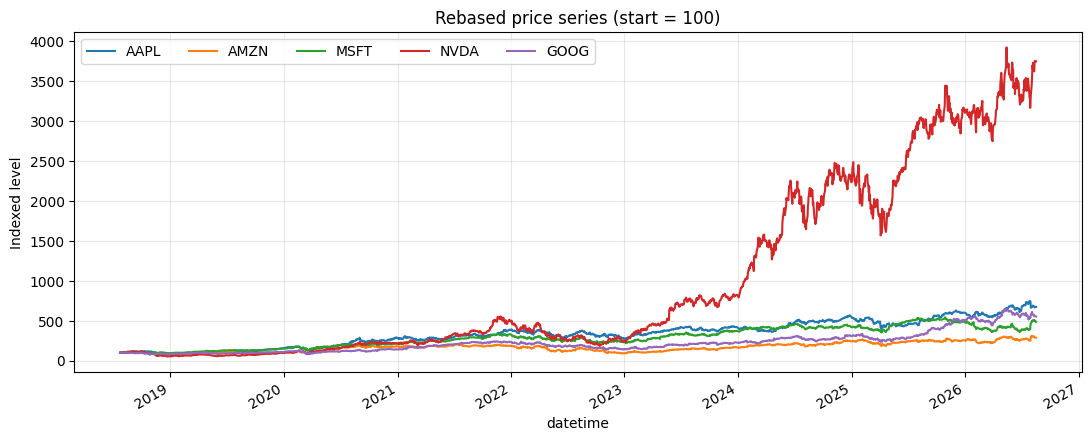

In [6]:
fig, ax = plt.subplots()
(prices / prices.iloc[0] * 100).plot(ax=ax)
ax.set_title("Rebased price series (start = 100)")
ax.set_ylabel("Indexed level")
ax.legend(loc="upper left", ncol=len(prices.columns))
plt.show()

## 2. Feature Engine output

Sanity-check the indicators the Strategy Engine actually trades on, for one
representative symbol -- if the fast/slow MAs or RSI look wrong here, everything
downstream is wrong too.

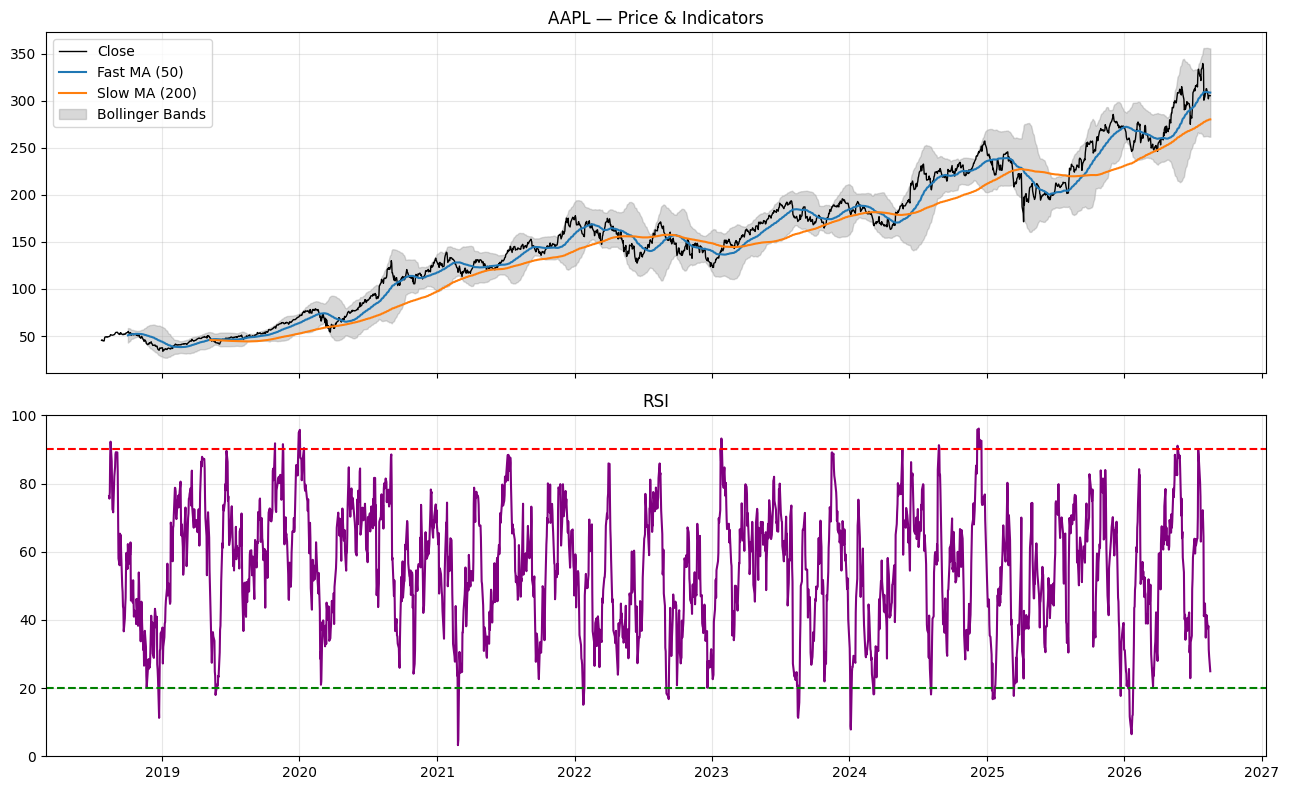

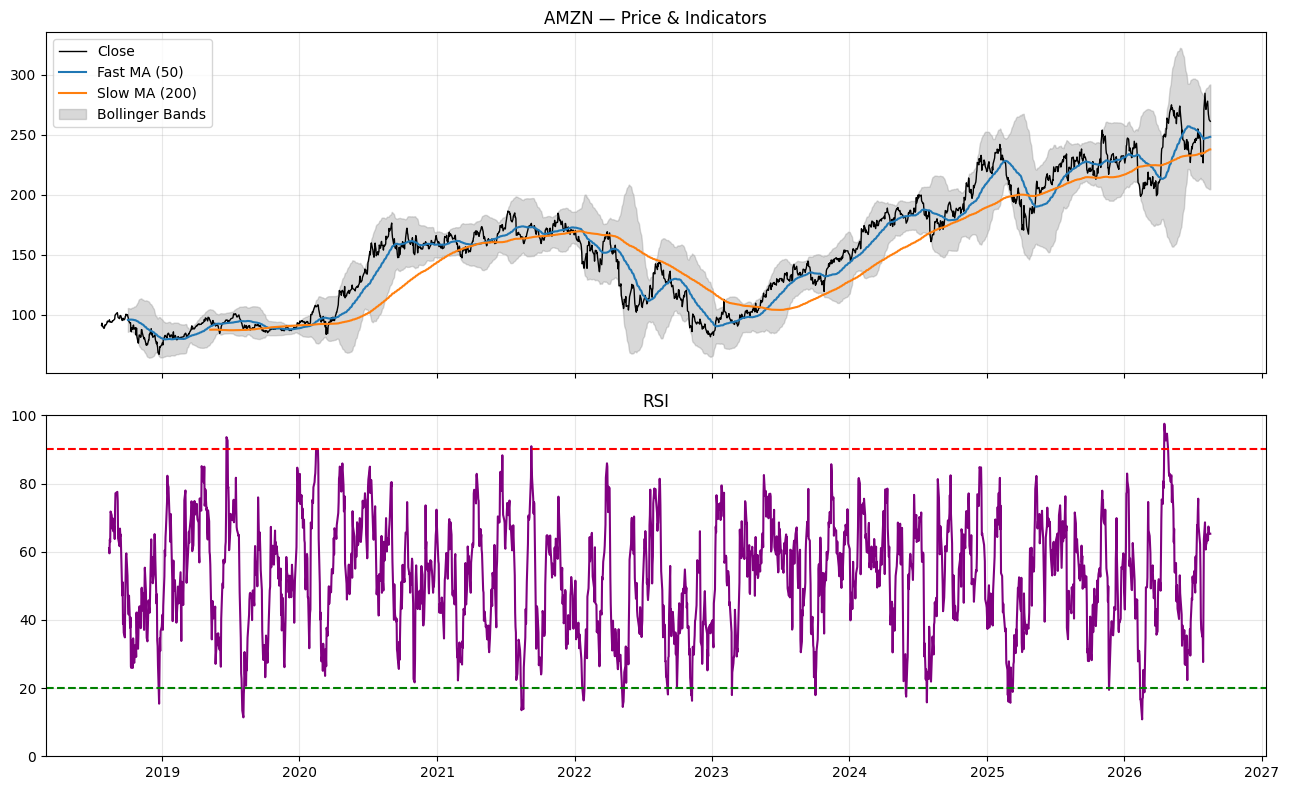

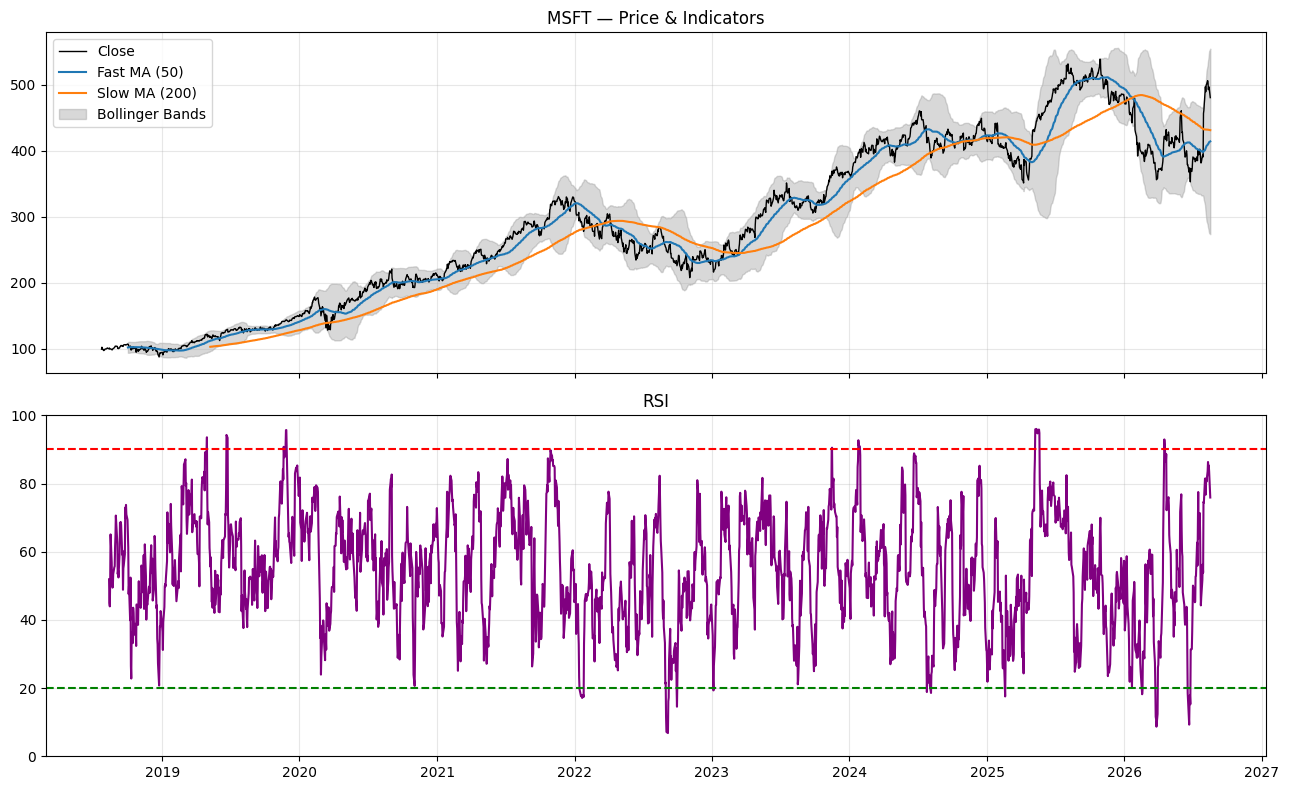

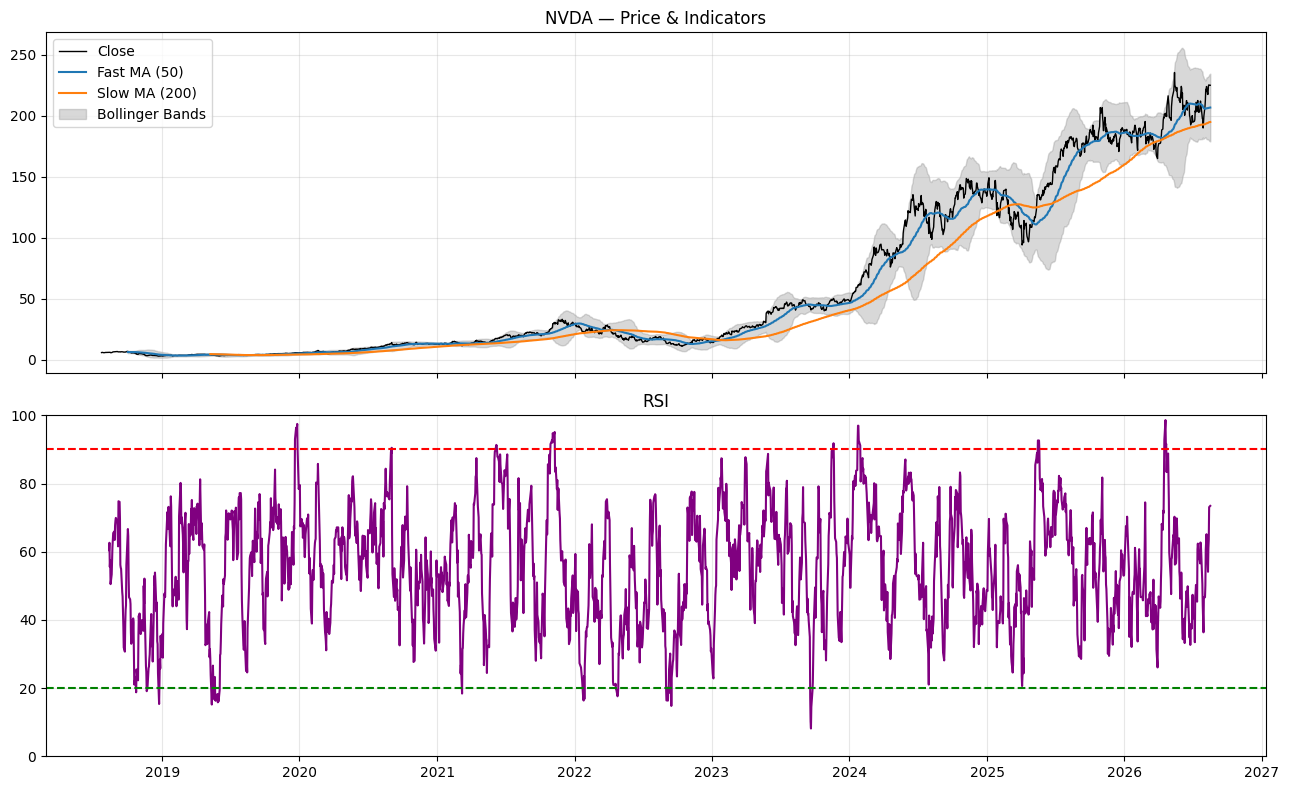

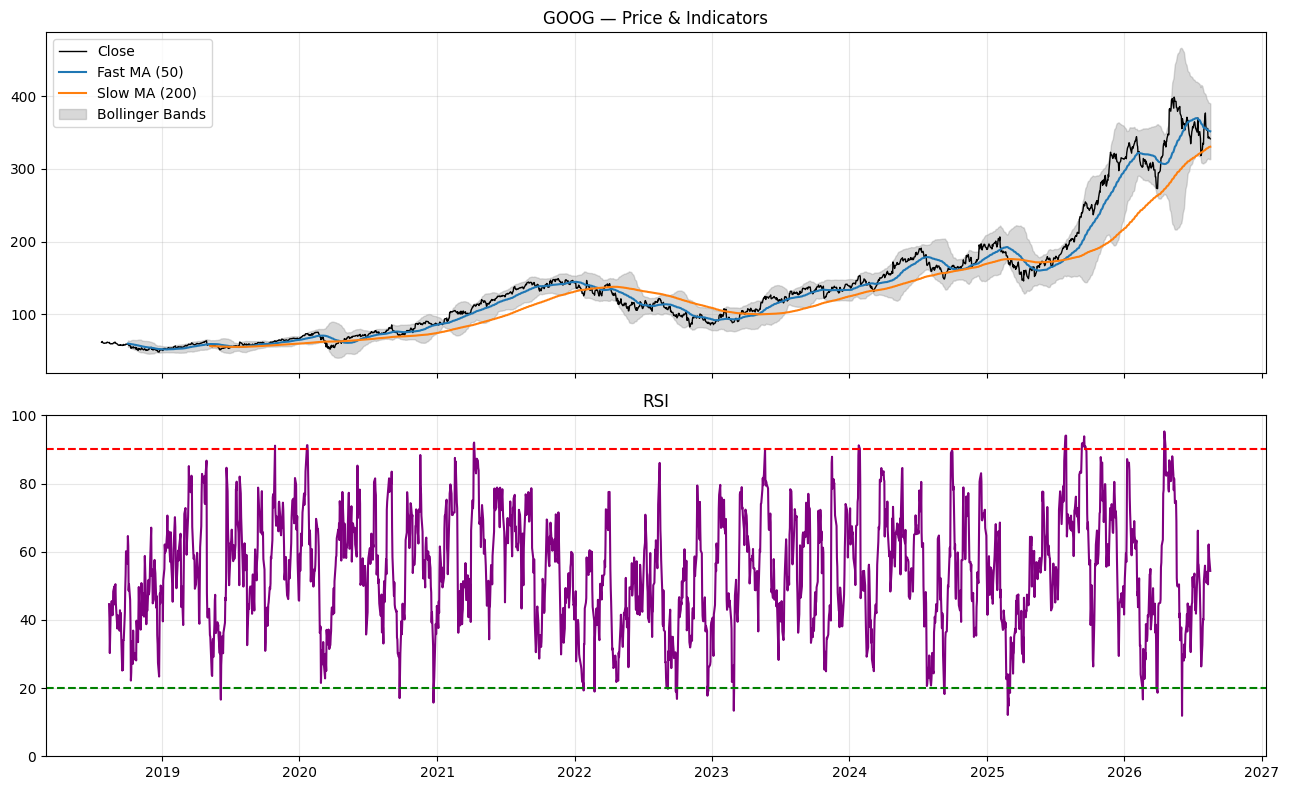

In [ ]:
fe = FeatureEngine()
features = fe.compute(prices)

# Flatten VectorBT parameter levels
for key, value in features.items():
    if isinstance(value, pd.DataFrame) and isinstance(value.columns, pd.MultiIndex):
        while value.columns.nlevels > 1:
            value = value.droplevel(0, axis=1)
        features[key] = value

for symbol in prices.columns:
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    axes[0].plot(prices.index, prices[symbol], label="Close", color="black", linewidth=1)
    axes[0].plot(prices.index, features["fast_ma"][symbol], label=f"Fast MA ({config.DEFAULT_STRATEGY.fast_window})")
    axes[0].plot(prices.index, features["slow_ma"][symbol], label=f"Slow MA ({config.DEFAULT_STRATEGY.slow_window})")
    axes[0].fill_between(prices.index, features["bb_lower"][symbol], features["bb_upper"][symbol], alpha=0.3, color="grey", label="Bollinger Bands")
    axes[0].set_title(f"{symbol} — Price & Indicators")
    axes[0].legend(loc="upper left")
    axes[1].plot(prices.index, features["rsi"][symbol], color="purple")
    axes[1].axhline(config.DEFAULT_STRATEGY.rsi_upper, color="red", linestyle="--")
    axes[1].axhline(config.DEFAULT_STRATEGY.rsi_lower, color="green", linestyle="--")
    axes[1].set_ylim(0, 100)
    axes[1].set_title("RSI")
    plt.tight_layout()
    plt.show()

## 3. Signals & sustained position state

`entries`/`exits` are crossover EVENTS (true only on the exact bar a cross fires).
`position_state` is the sustained "are we currently holding this name" state that
actually feeds the PortfolioAllocator -- plotting both together makes it obvious
whether the strategy is trading too often, too rarely, or spending most of its
time flat.

In [8]:
strategy = get_strategy(config.DEFAULT_STRATEGY.name)
sig_gen = SignalGenerator(strategy)

entries, exits = sig_gen.full_history_signals(prices)
position_state = signals_to_position_state(entries, exits)

signal_stats = pd.DataFrame({
    "n_entries": entries.sum(),
    "n_exits": exits.sum(),
    "pct_time_in_position": (position_state.mean() * 100).round(1),
    "avg_holding_days": (position_state.sum() / entries.sum().replace(0, np.nan)).round(1),
})
signal_stats

,n_entries,n_exits,pct_time_in_position,avg_holding_days
symbol,,,,
AAPL,4,4,34.0000,172.5000
AMZN,5,5,59.5000,241.2000
MSFT,3,4,31.3000,211.3000
NVDA,3,2,73.9000,499.0000
GOOG,4,4,67.9000,344.0000


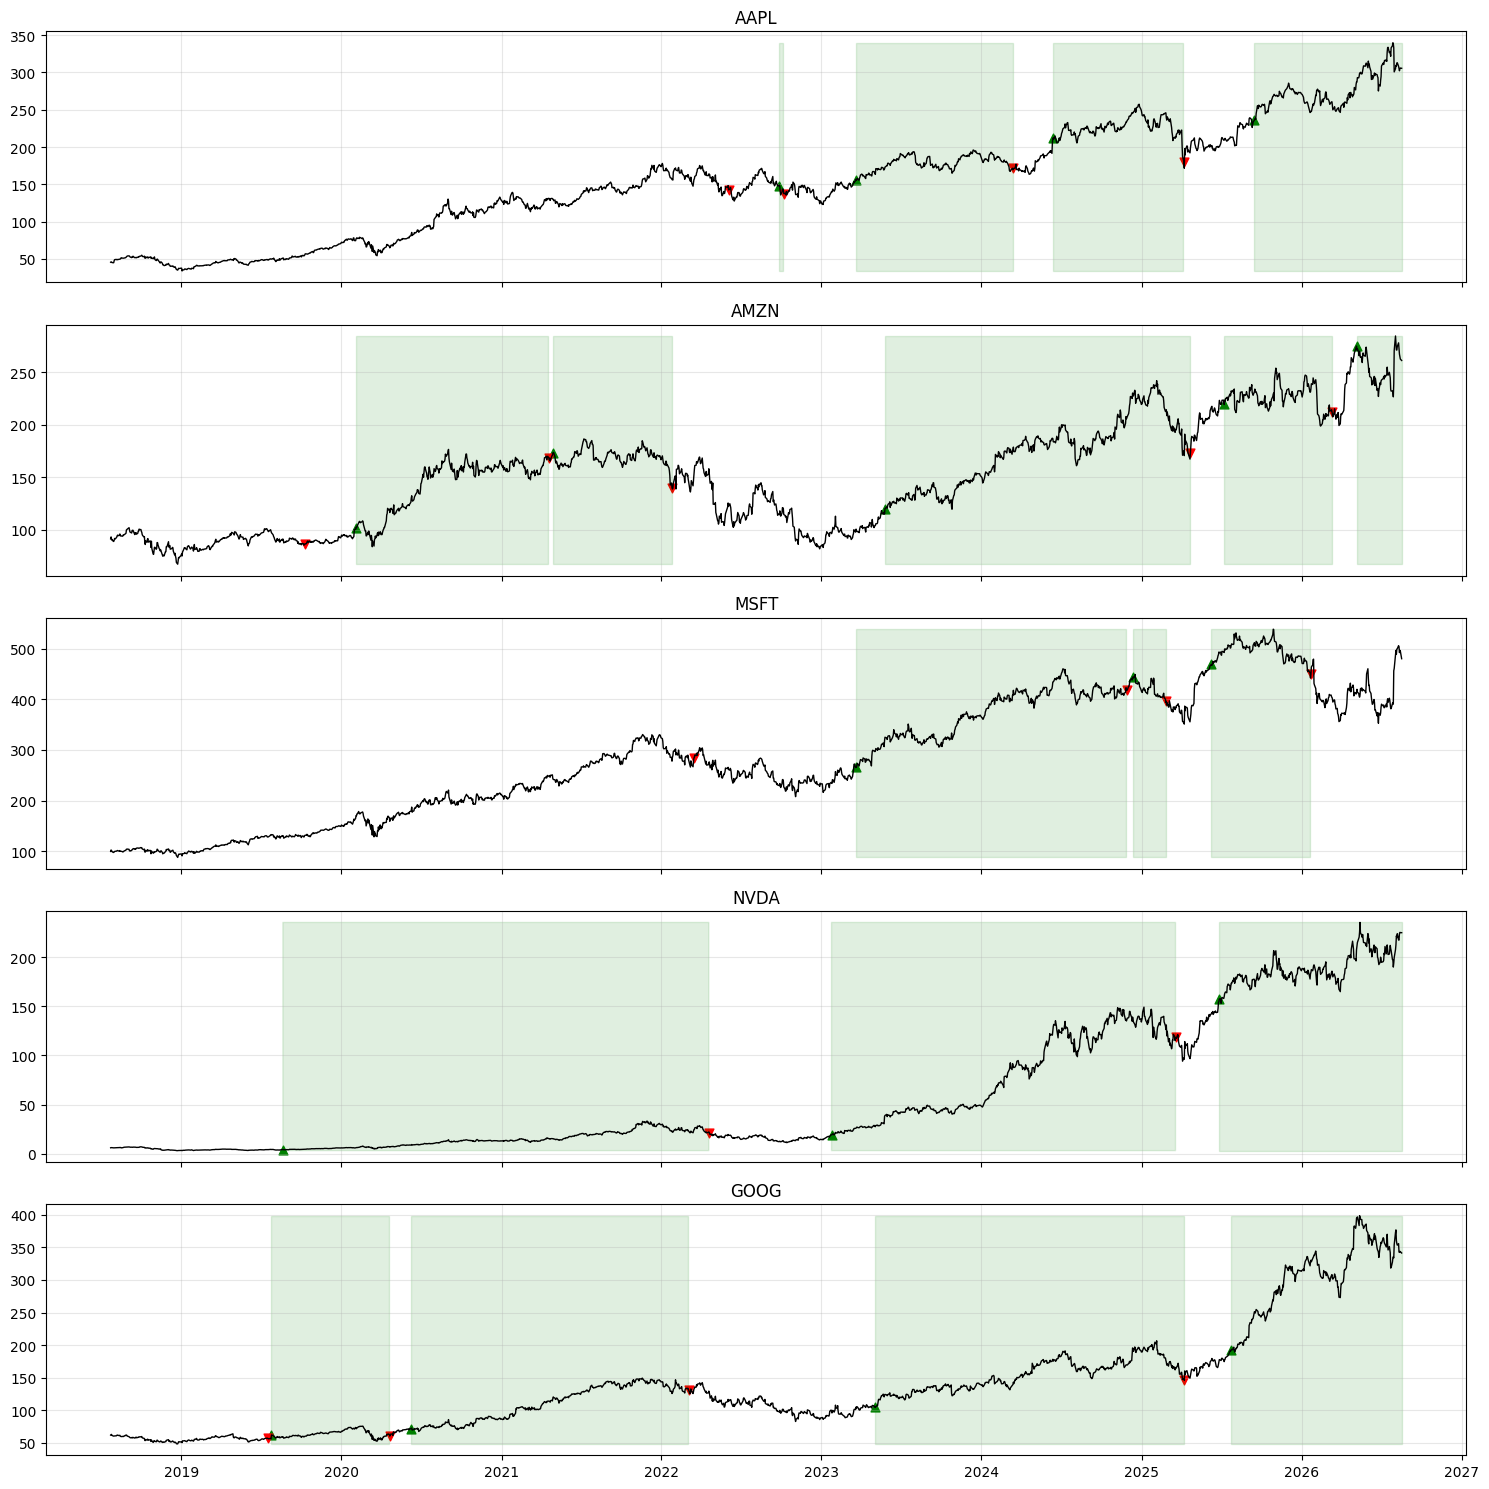

In [ ]:
fig, axes = plt.subplots(len(prices.columns), 1,
                         figsize=(15, 3*len(prices.columns)),
                         sharex=True)

for ax, symbol in zip(axes, prices.columns):
    price = prices[symbol]

    ax.plot(price.index, price, color="black", lw=1)
    ax.scatter(price.index[entries[symbol]], 
        price[entries[symbol]],
        marker="^",
        color="green",
        s=40,
    )
    ax.scatter(
        price.index[exits[symbol]],
        price[exits[symbol]],
        marker="v",
        color="red",
        s=40,
    )
    ax.fill_between(
        price.index,
        price.min(),
        price.max(),
        where=position_state[symbol].astype(bool),
        alpha=0.12,
        color="green",
    )
    ax.set_title(symbol)
plt.tight_layout()

## 4. PortfolioAllocator comparison

Same signals, same sizer, four different capital-allocation rules. This is the
question "given this signal is right, how should we size it" -- entirely separate
from "is the signal right" (section 3) or "did the sizing execute correctly"
(section 6).

In [10]:
results = {}
portfolios = {}

for strategy_name in STRATEGY_REGISTRY:

    # Generate signals for this strategy
    strategy = get_strategy(strategy_name)
    sig_gen = SignalGenerator(strategy)

    entries, exits = sig_gen.full_history_signals(prices)

    for allocator_name, (alloc_fn, alloc_kwargs) in ALLOCATORS.items():

        pf = run_backtest(
            prices,
            entries,
            exits,
            allocator=alloc_fn,
            allocator_kwargs=alloc_kwargs,
        )

        key = (strategy_name, allocator_name)

        results[key] = portfolio_level_stats(pf)
        portfolios[key] = pf

comparison = pd.DataFrame(results).T
comparison.index.names = ["strategy", "allocator"]
comparison

total_return  sharpe_ratio  \
strategy           allocator                                       
ma_crossover       equal_weight             0.6473        0.6227   
                   volatility_weight        0.6462        0.6266   
                   risk_parity              0.6386        0.6187   
                   kelly_weight             0.4153        0.5732   
rsi_mean_reversion equal_weight             0.4168        0.8862   
                   volatility_weight        0.3615        0.8357   
                   risk_parity              0.3769        0.8543   
                   kelly_weight             0.1310        0.2613   
bollinger_breakout equal_weight             0.0438        0.2772   
                   volatility_weight        0.0493        0.2981   
                   risk_parity              0.0480        0.2931   
                   kelly_weight             0.0537        0.2930   

                                      max_drawdown  total_orders  
strategy           allocator                                      
ma_crossover       equal_weight            -0.1250       34.0000  
                   volatility_weight       -0.1227       34.0000  
                   risk_parity             -0.1214       34.0000  
                   kelly_weight            -0.1144       28.0000  
rsi_mean_reversion equal_weight            -0.0950      159.0000  
                   volatility_weight       -0.0961      160.0000  
                   risk_parity             -0.0968      161.0000  
                   kelly_weight            -0.0576       82.0000  
bollinger_breakout equal_weight            -0.0662       93.0000  
                   volatility_weight       -0.0648       93.0000  
                   risk_parity             -0.0648       93.0000  
                   kelly_weight            -0.0564       85.0000

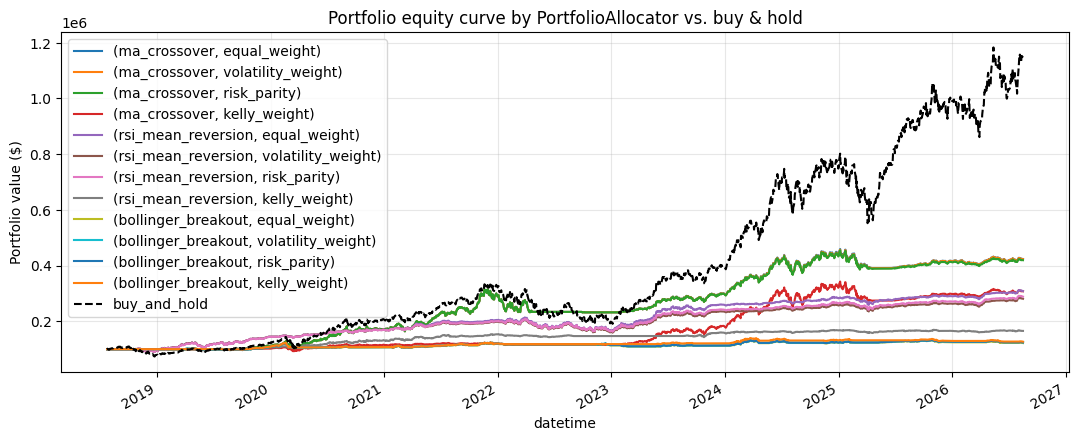

In [11]:
fig, ax = plt.subplots()
for name, pf in portfolios.items():
    equity, _ = portfolio_equity(pf, prices)
    equity.plot(ax=ax, label=name)
hold_pf = run_buy_and_hold(prices)
hold_equity, _ = portfolio_equity(hold_pf, prices)
hold_equity.plot(
    ax=ax,
    label="buy_and_hold",
    color="black",
    linestyle="--"
)
ax.set_title("Portfolio equity curve by PortfolioAllocator vs. buy & hold")
ax.set_ylabel("Portfolio value ($)")
ax.legend()
plt.show()

## 5. Deep dive: chosen allocator

Pick the allocator that came out ahead above (or the one you intend to run live)
and look at it the way a PM will actually look at it: equity curve, drawdown,
rolling risk-adjusted return, and a monthly return table.

In [ ]:
CHOSEN_STRATEGY = config.DEFAULT_STRATEGY.name
CHOSEN_ALLOCATOR = "equal_weight"
pf = portfolios[(CHOSEN_STRATEGY, CHOSEN_ALLOCATOR)]
print("=== Per-symbol summary ===")
display(summary_stats(pf))
print("\n=== True Portfolio Stats ===")
equity, returns = portfolio_equity(pf, 
    prices
)
display(
    true_portfolio_stats(
        equity,
        returns,
        pf
    )
)


=== Per-symbol summary ===


,total_return,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,win_rate,total_trades,avg_trade_return
symbol,,,,,,,,
AAPL,0.0357,0.1769,0.2344,0.0920,-0.0689,0.5000,4,0.0434
AMZN,0.1823,0.4368,0.6378,0.2433,-0.1259,0.4000,5,0.1636
MSFT,0.1114,0.4932,0.6960,0.3013,-0.0637,0.3333,3,0.1416
NVDA,2.4193,1.1214,1.6744,0.9409,-0.2634,1.0000,3,3.2267
GOOG,0.4875,0.8850,1.2811,0.7206,-0.1029,0.7500,4,0.4892



=== True Portfolio Stats ===


final_equity   423,629.5806
total_return         3.2363
sharpe_ratio         0.9785
max_drawdown        -0.2637
total_orders        34.0000
total_trades        19.0000
dtype: float64

In [13]:
pf_hold = run_buy_and_hold(prices)
hold_equity, hold_returns = portfolio_equity(
    pf_hold,
    prices
)
print("\n=== Buy & Hold True Portfolio Stats ===")
display(
    true_portfolio_stats(
        hold_equity,
        hold_returns,
        pf_hold
    )
)


=== Buy & Hold True Portfolio Stats ===


final_equity   1,146,667.4673
total_return          10.4701
sharpe_ratio           1.0939
max_drawdown          -0.4270
total_orders           5.0000
total_trades           5.0000
dtype: float64

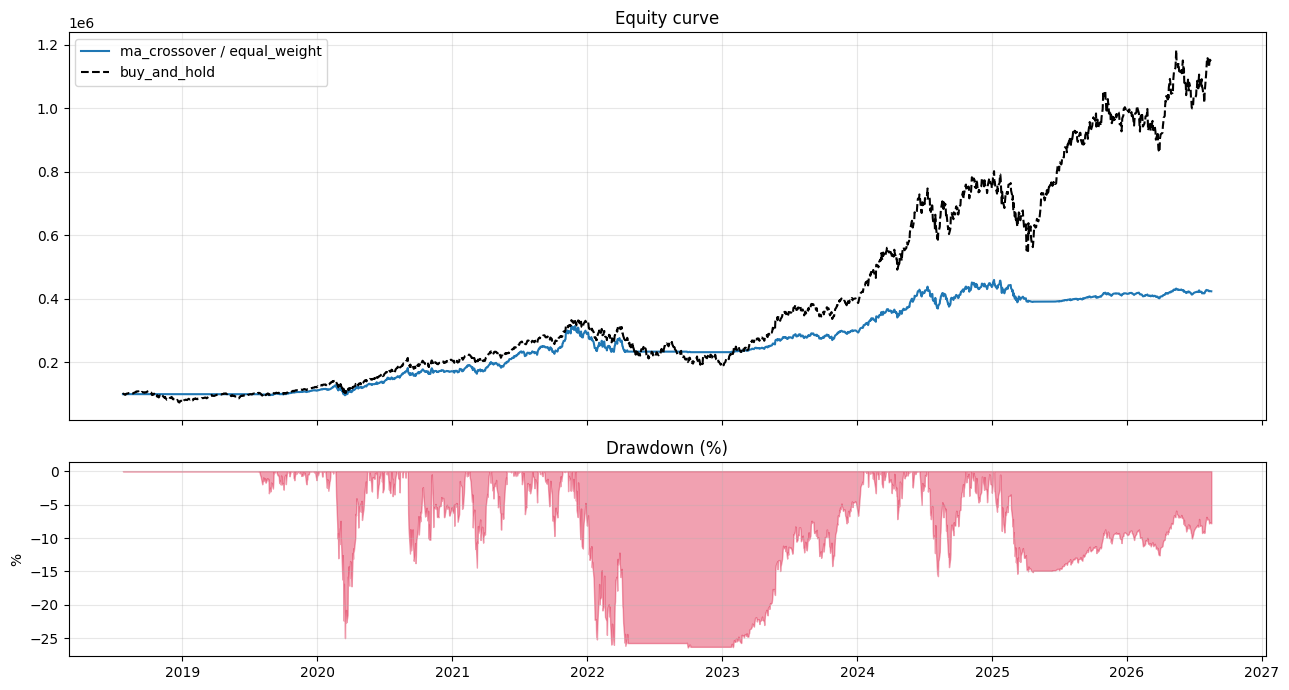

Max drawdown: -26.37%


In [14]:
equity, daily_returns = portfolio_equity(
    pf,
    prices
)
benchmark_equity, _ = portfolio_equity(
    pf_hold,
    prices
)
running_max = equity.cummax()
drawdown = (equity - running_max) / running_max

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(equity.index, equity, label=f"{CHOSEN_STRATEGY} / {CHOSEN_ALLOCATOR}")
axes[0].plot(benchmark_equity.index, benchmark_equity, label="buy_and_hold", color="black", linestyle="--")
axes[0].set_title("Equity curve")
axes[0].legend()

axes[1].fill_between(drawdown.index, drawdown * 100, 0, color="crimson", alpha=0.4)
axes[1].set_title("Drawdown (%)")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()
print(f"Max drawdown: {drawdown.min() * 100:.2f}%")

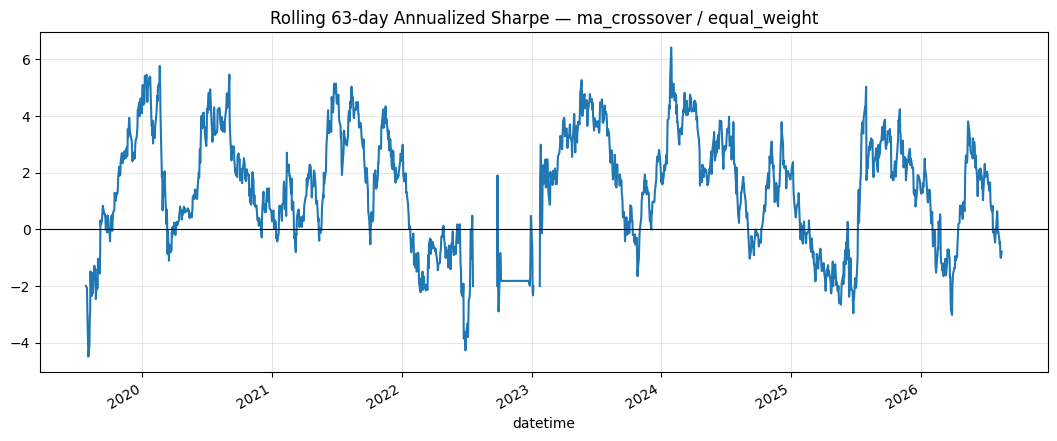

In [15]:
rolling_window = 63

rolling_sharpe = (
    daily_returns.rolling(rolling_window).mean()
    / daily_returns.rolling(rolling_window).std()
) * np.sqrt(252)

fig, ax = plt.subplots()

rolling_sharpe.plot(ax=ax)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(
    f"Rolling {rolling_window}-day Annualized Sharpe — "
    f"{CHOSEN_STRATEGY} / {CHOSEN_ALLOCATOR}"
)

plt.show()

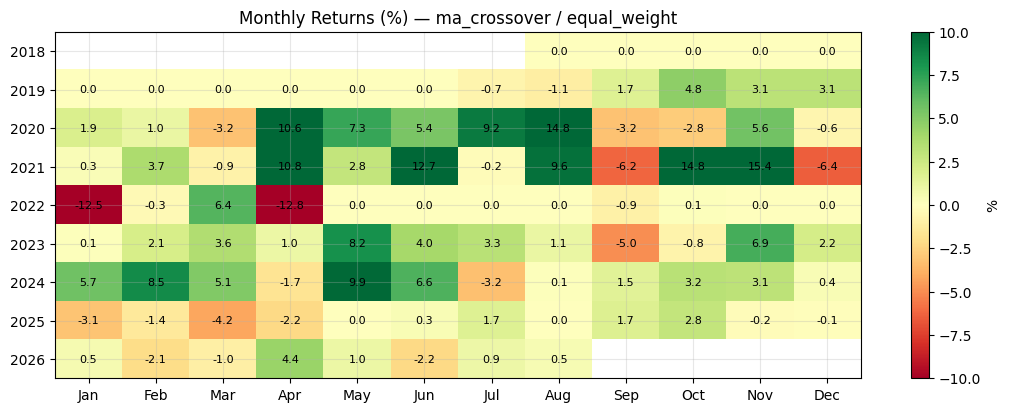

In [16]:
monthly = equity.resample("ME").last().pct_change().dropna()
monthly_table = monthly.to_frame("return")
monthly_table["year"] = monthly_table.index.year
monthly_table["month"] = monthly_table.index.strftime("%b")
pivot = monthly_table.pivot(index="year", columns="month", values="return")
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])

fig, ax = plt.subplots(figsize=(13, max(2, 0.5 * len(pivot))))
im = ax.imshow((pivot * 100).values, cmap="RdYlGn", vmin=-10, vmax=10, aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val*100:.1f}", ha="center", va="center", fontsize=8)
ax.set_title(
    f"Monthly Returns (%) — "
    f"{CHOSEN_STRATEGY} / {CHOSEN_ALLOCATOR}"
)
fig.colorbar(im, ax=ax, label="%")
plt.show()

## 6. Trade-level diagnostics

Aggregate stats can hide a strategy that makes its money on one lucky trade, or
that has a win rate so low it will be psychologically hard to trade live even if
the expectancy is positive.

In [17]:
trades = pf.trades.records_readable.copy()
trades["Symbol"] = trades["Column"].apply(
    lambda x: x[-1] if isinstance(x, tuple) else x
)
trades = trades.sort_values("Entry Timestamp")
print(f"Total trades across universe: {len(trades)}")
display(trades[["Symbol", "Entry Timestamp", "Exit Timestamp", "PnL", "Return"]])

best_trade = trades.loc[trades["PnL"].idxmax()]
worst_trade = trades.loc[trades["PnL"].idxmin()]

print("=== BEST TRADE ===")
display(best_trade)
print("\n=== WORST TRADE ===")
display(worst_trade)

Total trades across universe: 19


,Symbol,Entry Timestamp,Exit Timestamp,PnL,Return
15,GOOG,2019-07-26,2020-04-21,-691.8212,-0.0277
12,NVDA,2019-08-21,2022-04-20,"102,447.6950",4.0974
4,AMZN,2020-02-05,2021-04-19,"16,299.5620",0.6522
16,GOOG,2020-06-08,2022-03-04,"20,604.8017",0.8256
5,AMZN,2021-04-29,2022-01-25,"-4,849.0659",-0.1940
0,AAPL,2022-09-26,2022-10-07,"-1,776.7107",-0.0714
13,NVDA,2023-01-24,2025-03-20,"128,828.3464",5.1550
9,MSFT,2023-03-20,2024-11-29,"14,375.8754",0.5762
1,AAPL,2023-03-22,2024-03-14,"2,520.3180",0.1013
17,GOOG,2023-05-03,2025-04-08,"9,651.7413",0.3871


=== BEST TRADE ===


Exit Trade Id                       13
Column                    (NVDA, NVDA)
Size                        1,300.0000
Entry Timestamp    2023-01-24 00:00:00
Avg Entry Price                19.2238
Entry Fees                      2.4991
Exit Timestamp     2025-03-20 00:00:00
Avg Exit Price                118.3363
Exit Fees                      15.3837
PnL                       128,828.3464
Return                          5.1550
Direction                         Long
Status                          Closed
Position Id                         13
Symbol                            NVDA
Name: 13, dtype: object


=== WORST TRADE ===


Exit Trade Id                        5
Column                    (AMZN, AMZN)
Size                          144.0000
Entry Timestamp    2021-04-29 00:00:00
Avg Entry Price               173.6047
Entry Fees                      2.4999
Exit Timestamp     2022-01-25 00:00:00
Avg Exit Price                139.9620
Exit Fees                       2.0155
PnL                        -4,849.0659
Return                         -0.1940
Direction                         Long
Status                          Closed
Position Id                          5
Symbol                            AMZN
Name: 5, dtype: object

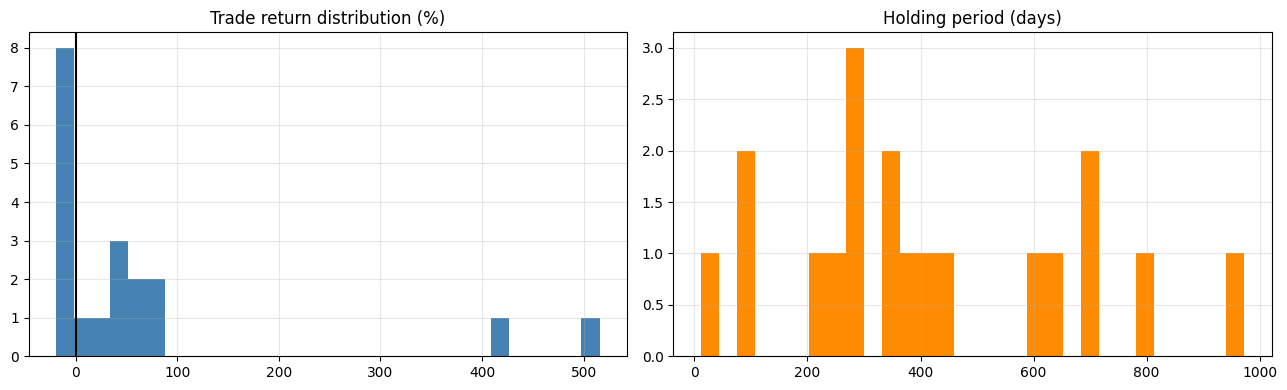

Win rate: 57.9%   Profit factor: 21.78   Avg holding period: 413.5 days


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
trades["Return"].mul(100).hist(bins=30, ax=axes[0], color="steelblue")
axes[0].axvline(0, color="black")
axes[0].set_title("Trade return distribution (%)")

holding_days = (pd.to_datetime(trades["Exit Timestamp"]) - pd.to_datetime(trades["Entry Timestamp"])).dt.days
holding_days.hist(bins=30, ax=axes[1], color="darkorange")
axes[1].set_title("Holding period (days)")
plt.tight_layout()
plt.show()

win_rate = (trades["PnL"] > 0).mean()
profit_factor = trades.loc[trades["PnL"] > 0, "PnL"].sum() / abs(trades.loc[trades["PnL"] < 0, "PnL"].sum())
print(f"Win rate: {win_rate*100:.1f}%   Profit factor: {profit_factor:.2f}   "
      f"Avg holding period: {holding_days.mean():.1f} days")

## 7. Exposure sanity check

A quick self-audit of the sizing pipeline: gross exposure should never exceed
`config.RISK.max_gross_exposure` (the red dashed line). If it does, that's a bug
in `portfolio_engine`/`backtester`, not a property of the strategy -- worth
checking before trusting anything above.

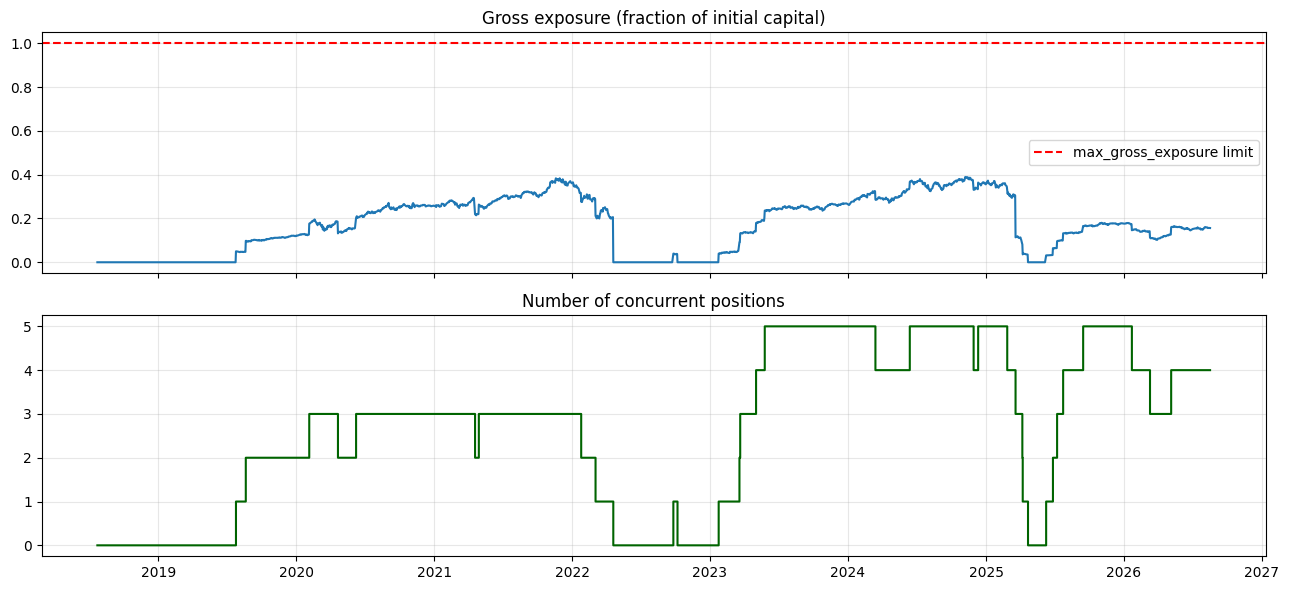

Bars where gross exposure exceeded the limit: 0 / 2027


In [19]:
shares = pf.assets()

if isinstance(shares.columns, pd.MultiIndex):
    shares.columns = shares.columns.get_level_values(-1)

aligned_prices = prices.reindex(index=shares.index, columns=shares.columns)
position_values = shares.abs() * aligned_prices
gross_position_value = position_values.sum(axis=1)
portfolio_equity = pf.value().sum(axis=1)
gross_exposure = (gross_position_value / portfolio_equity)
n_positions = (shares.abs() > 0).sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(gross_exposure.index, gross_exposure)
axes[0].axhline(config.RISK.max_gross_exposure, color="red", linestyle="--", label="max_gross_exposure limit")
axes[0].set_title("Gross exposure (fraction of initial capital)")
axes[0].legend()

axes[1].plot(n_positions.index, n_positions, drawstyle="steps-post", color="darkgreen")
axes[1].set_title("Number of concurrent positions")
plt.tight_layout()
plt.show()

breaches = (gross_exposure > config.RISK.max_gross_exposure + 1e-6).sum()
print(f"Bars where gross exposure exceeded the limit: {breaches} / {len(gross_exposure)}")

## 8. Save tearsheet

Persist the per-symbol summary stats for the chosen allocator to `reports/` for
the record -- this is what would get attached to a strategy proposal.

In [20]:
from performance_analytics import save_tearsheet
path = save_tearsheet(pf, name=f"{strategy.name}_{CHOSEN_ALLOCATOR}_research")
print(f"Saved to {path}")

Saved to /Users/davidyekara/Downloads/Algorithmic Trading Cookbook/VectorBT/Technical Strategies/reports/bollinger_breakout_equal_weight_research_20260818_020737.csv


## 9. Conclusions (fill in before circulating)

- **Signal quality:** does section 3's entry/exit behavior match the intended
  strategy logic? Any obviously wrong bunching of trades?
- **Allocator choice:** which PortfolioAllocator from section 4 will actually be
  proposed, and why (return? risk-adjusted return? drawdown? turnover?).
- **Exposure:** did section 7 show any gross-exposure breaches? If so, stop here
  and fix the sizing pipeline before going further.
- **Next step:** if this looks promising, take it to `walk_forward.ipynb` for an
  out-of-sample robustness check before it goes anywhere near
  `portfolio_analysis.ipynb` / production.